# Variational Autoencoder (VAE)

**Thực hành cơ bản về VAE & CVAE**

Notebook này bao gồm các nội dung:
- Encoder: Ánh xạ dữ liệu vào phân phối không gian tiềm ẩn (latent distribution).
- Reparameterization trick (Thủ thuật tham số hóa lại).
- Decoder: Ánh xạ từ không gian tiềm ẩn ra ảnh tái tạo.
- VAE loss = Reconstruction loss + KL divergence.
- Trực quan hóa không gian tiềm ẩn (Latent space visualization).
- Nội suy (Interpolation) và Sinh mẫu mới (Generating new samples).

---

**Setup & Imports**




In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
LATENT_DIM = 2  # Sử dụng 2D để dễ dàng trực quan hóa
print(f'Device: {device}')

Device: cuda


## 1. Chuẩn bị dữ liệu (Dataset & DataLoader)
Sử dụng tập dữ liệu ảnh chữ số viết tay MNIST (ảnh grayscale $28 \times 28$).

In [ ]:
transform = transforms.Compose([transforms.ToTensor()])
train_data = torchvision.datasets.MNIST('./data', train=True, download=True, transform=transform)
val_data = torchvision.datasets.MNIST('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
val_loader = DataLoader(val_data, batch_size=512, shuffle=False)
print(f'Input shape: {train_data[0][0].shape}')  # Kết quả mong đợi: (1, 28, 28)

100%|██████████| 9.91M/9.91M [00:01<00:00, 4.96MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 127kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.02MB/s]

Input shape: torch.Size([1, 28, 28])


## 2. Define VAE (Xây dựng mô hình VAE)



Dưới đây là sơ đồ kiến trúc của VAE và CVAE:



<p align="center">

  <img src="## 2. Kiến trúc VAE (Variational Autoencoder)



Không giống Autoencoder thông thường map input ra một vector cố định, **VAE map input ra một phân phối xác suất**.

<p align="center">

  <img src="https://www.researchgate.net/publication/370687768/figure/fig1/AS:11431281202080338@1698723661544/The-fundamental-mechanisms-of-the-VAE-a-and-CVAE-b.png" width="700">

</p>



**Mapping Lý thuyết & Code:**

1. **Encoder:** Tính toán giá trị trung bình $\mu$ (mu) và phương sai $\sigma^2$ (được biểu diễn qua log-variance `logvar` để đảm bảo tính ổn định).

2. **Reparameterization Trick:** Vì không thể tính đạo hàm qua một quá trình lấy mẫu ngẫu nhiên (sampling), ta dùng trick:

   $$z = \mu + \sigma \odot \epsilon$$

   Trong đó $\epsilon \sim \mathcal{N}(0, 1)$ (một nhiễu Gaussian chuẩn).

3. **Decoder:** Tái tạo lại ảnh từ vector tiềm ẩn (latent vector) $z$.

" width="700">

In [ ]:
class VAE(nn.Module):
    def __init__(self, latent_dim: int = 2):
        super().__init__()
        self.latent_dim = latent_dim

        # --- Encoder ---
        self.encoder = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        # --- Decoder ---
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Sigmoid() # Đưa pixel về khoảng [0, 1]
        )

    def encode(self, x):
        x = x.view(x.size(0), -1)  # Flatten: (Batch_size, 784)
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        # Tính độ lệch chuẩn (std) từ logvar
        std = torch.exp(0.5 * logvar)
        # Lấy mẫu nhiễu epsilon từ phân phối chuẩn N(0, I)
        eps = torch.randn_like(std)
        # z = mu + sigma * epsilon
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z).view(-1, 1, 28, 28)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

model = VAE(latent_dim=LATENT_DIM).to(device)
print(model)

VAE(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
  )
  (fc_mu): Linear(in_features=256, out_features=2, bias=True)
  (fc_logvar): Linear(in_features=256, out_features=2, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


## 3. VAE Loss Function
Hàm mục tiêu ELBO bao gồm:
1. **Reconstruction loss (BCE):** Đánh giá mức độ khớp giữa ảnh tái tạo và ảnh gốc.
2. **KL Divergence loss:** Ép phân phối của latent space xấp xỉ với phân phối chuẩn.

In [ ]:
def vae_loss(x_recon, x, mu, logvar, beta=1.0):
    # Reconstruction loss (BCE)
    recon_loss = F.binary_cross_entropy(x_recon.view(-1, 784), x.view(-1, 784), reduction='sum')

    # KL Divergence loss
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    # Trung bình trên batch
    batch_size = x.size(0)
    recon_loss /= batch_size
    kl_loss /= batch_size

    total_loss = recon_loss + beta * kl_loss
    return total_loss, recon_loss, kl_loss

## 4. Training Loop (Vòng lặp huấn luyện)
Sử dụng Adam Optimizer với learning rate = 1e-3, huấn luyện trong 10 epochs.

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 10

model.train()
for epoch in range(epochs):
    train_loss, train_recon, train_kl = 0.0, 0.0, 0.0

    for x, _ in train_loader:
        x = x.to(device)

        optimizer.zero_grad()
        x_recon, mu, logvar = model(x)

        loss, recon_loss, kl_loss = vae_loss(x_recon, x, mu, logvar)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_recon += recon_loss.item()
        train_kl += kl_loss.item()

    num_batches = len(train_loader)
    print(f"Epoch {epoch+1:02d}/{epochs} | "
          f"Total Loss: {train_loss/num_batches:.4f} | "
          f"Recon: {train_recon/num_batches:.4f} | "
          f"KL: {train_kl/num_batches:.4f}")

Epoch 01/10 | Total Loss: 182.2500 | Recon: 178.0879 | KL: 4.1621
Epoch 02/10 | Total Loss: 159.8479 | Recon: 154.4440 | KL: 5.4038
Epoch 03/10 | Total Loss: 154.0751 | Recon: 148.3322 | KL: 5.7429
Epoch 04/10 | Total Loss: 150.7523 | Recon: 144.8239 | KL: 5.9284
Epoch 05/10 | Total Loss: 148.6324 | Recon: 142.5691 | KL: 6.0633
Epoch 06/10 | Total Loss: 147.0762 | Recon: 140.9066 | KL: 6.1696
Epoch 07/10 | Total Loss: 145.8168 | Recon: 139.5613 | KL: 6.2555
Epoch 08/10 | Total Loss: 144.6844 | Recon: 138.3673 | KL: 6.3171
Epoch 09/10 | Total Loss: 143.6945 | Recon: 137.3178 | KL: 6.3767
Epoch 10/10 | Total Loss: 142.9534 | Recon: 136.5225 | KL: 6.4310


## 5. Visualize Reconstructions (Trực quan hóa ảnh tái tạo)
So sánh ảnh gốc (Original) và ảnh được mạng VAE tái tạo lại (Reconstructed).

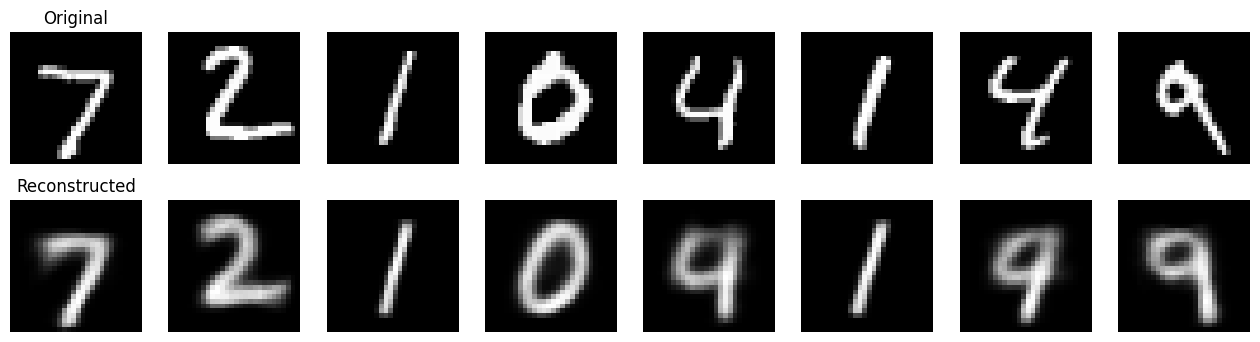

In [ ]:
model.eval()
with torch.no_grad():
    data, _ = next(iter(val_loader))
    data = data.to(device)
    recon_data, _, _ = model(data)

    n = 8
    plt.figure(figsize=(16, 4))
    for i in range(n):
        # Ảnh gốc
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(data[i].cpu().squeeze(), cmap='gray')
        ax.axis('off')
        if i == 0: ax.set_title("Original")

        # Ảnh tái tạo
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(recon_data[i].cpu().squeeze(), cmap='gray')
        ax.axis('off')
        if i == 0: ax.set_title("Reconstructed")
    plt.show()

## 6. Latent Space Visualization (Trực quan hóa không gian tiềm ẩn)
Chiếu toàn bộ tập Validation xuống không gian 2D để xem VAE phân cụm các chữ số như thế nào.

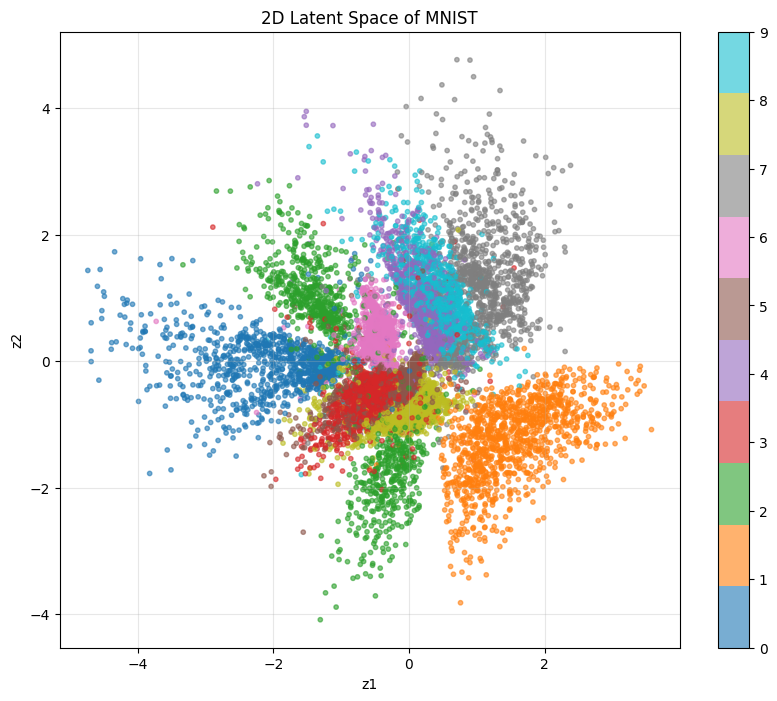

In [ ]:
model.eval()
z_points = []
labels_list = []

with torch.no_grad():
    for x, labels in val_loader:
        x = x.to(device)
        mu, _ = model.encode(x)
        z_points.append(mu.cpu().numpy())
        labels_list.append(labels.numpy())

z_points = np.concatenate(z_points, axis=0)
labels_list = np.concatenate(labels_list, axis=0)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(z_points[:, 0], z_points[:, 1], c=labels_list, cmap='tab10', alpha=0.6, s=10)
plt.colorbar(scatter, ticks=range(10))
plt.title("2D Latent Space of MNIST")
plt.xlabel("z1")
plt.ylabel("z2")
plt.grid(True, alpha=0.3)
plt.show()

## 7. Latent Interpolation (Nội suy trong không gian tiềm ẩn)
Kiểm tra tính liên tục của Latent Space bằng cách chuyển dần từ chữ số này sang chữ số khác.

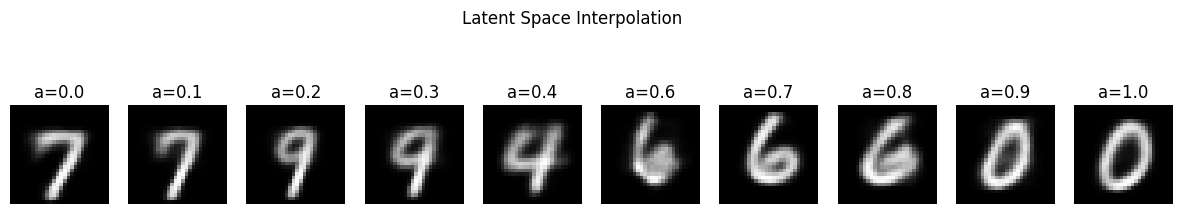

In [ ]:
model.eval()
with torch.no_grad():
    x, labels = next(iter(val_loader))
    x1, x2 = x[0].to(device), x[3].to(device) # Chọn 2 ảnh bất kỳ

    mu1, _ = model.encode(x1.unsqueeze(0))
    mu2, _ = model.encode(x2.unsqueeze(0))

    steps = 10
    alphas = torch.linspace(0, 1, steps).to(device)

    plt.figure(figsize=(15, 3))
    for i, alpha in enumerate(alphas):
        z_interp = (1 - alpha) * mu1 + alpha * mu2
        recon_interp = model.decode(z_interp)

        ax = plt.subplot(1, steps, i + 1)
        plt.imshow(recon_interp.cpu().squeeze(), cmap='gray')
        ax.axis('off')
        ax.set_title(f"a={alpha.item():.1f}")
    plt.suptitle("Latent Space Interpolation")
    plt.show()

## 8. Generate New Samples (Sinh mẫu mới)
Lấy các vector ngẫu nhiên $z \sim \mathcal{N}(0, I)$ đưa qua Decoder để tạo ra những chữ số chưa từng tồn tại.

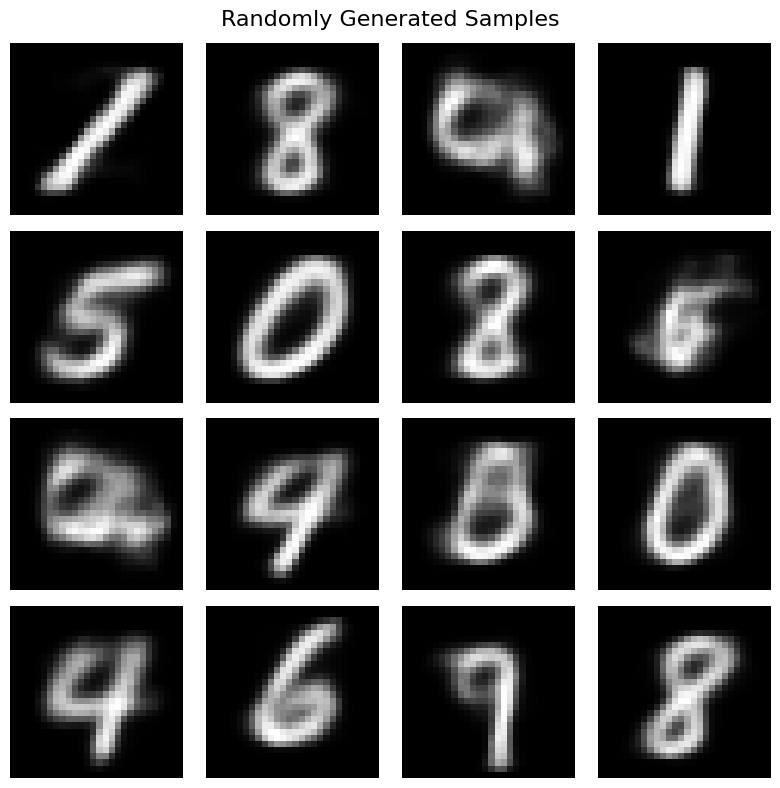

In [ ]:
model.eval()
with torch.no_grad():
    # Lấy mẫu 16 vector z ngẫu nhiên
    z_random = torch.randn(16, LATENT_DIM).to(device)
    generated_images = model.decode(z_random)

    plt.figure(figsize=(8, 8))
    for i in range(16):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(generated_images[i].cpu().squeeze(), cmap='gray')
        ax.axis('off')
    plt.suptitle("Randomly Generated Samples", fontsize=16)
    plt.tight_layout()
    plt.show()